# Module 22: Principal Component Analysis (PCA)

Ei notebook e amra PCA ke ekta library (scikit-learn) diye, ekta chhoto o clear dataset e step-by-step dekhbo.

### Ki ki shikhbo
1. PCA keno lagbe (theory chara practical reason)
2. Data prepare kora — biseshoto **scaling**, ja prai shomoy optional na
3. PCA fit kore **explained variance ratio** bujha
4. Koyta component rakhbo shetar jonno ekta clear rule (jemon 90% ba 95% variance)
5. Dataset ke PCA space e transform kora
6. PC1, PC2 diye 2D visualization
7. PCA soho o chara model performance compare kora (choto demo)

### Mone rakhar moto ekta kotha
PCA original feature **select** kore na. Eta **notun feature** (principal components) toiri kore, jegulo original feature gulor combination.

## 1) Import o Setup

Amra use korbo:
- `sklearn.datasets` — ekta chhoto dataset er jonno
- `StandardScaler` — scaling er jonno
- `PCA` — dimensionality reduction er jonno
- `matplotlib` — plot korar jonno

**Scaling keno lagbe?**
PCA variance-based. Kono feature-er numeric scale boro hole, shetai variance e dominate korbe ebong PCA ke hijack korte pare. Scaling shob feature ke comparable kore, jate PCA আসল structure dhorte pare, unit-er difference na।

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

## 2) Dataset Load Kora (CSV theke)

Amra use korbo **`student_performance_300.csv`** — ekta synthetic student performance dataset:
- 350 samples (row)
- 12 numeric feature
- Ekta `final_score` column ke amra "target" hisebe use korbo , kintu PCA fit korar shomoy eta use hobe na



In [ ]:
csv_path = "/content/student_performance_300.csv"

df_raw = pd.read_csv(csv_path)
print(df_raw.shape)
df_raw.head()

(350, 12)


,study_hour,attendance_pct,sleep_hour,screen_time_hour,prev_gpa,assignment_score,quiz_score,midterm_score,final_score,extracurricular_hours,commute_time_min,family_income
0,6.61,86.0,8.34,5.53,4.00,68.7,70.1,66.6,62.5,4.54,27.1,58867.0
1,3.92,76.4,6.71,9.77,3.35,59.5,47.9,56.3,59.2,2.18,45.9,38870.0
2,7.50,82.9,5.76,6.66,4.00,73.4,65.7,75.2,73.5,4.84,37.6,29693.0
3,7.88,95.9,6.93,9.79,4.00,75.9,79.3,70.9,62.5,3.73,15.7,44774.0
4,2.10,69.0,8.26,9.84,2.79,69.4,66.3,66.7,58.2,2.78,31.9,51373.0


In [ ]:
# PCA-r jonno amra label/target column alada kore rakhbo (ekhane: final_score)
# eta PCA fit-e use hobe na

target_col = "final_score"

X = df_raw.drop(columns=[target_col])
y = df_raw[target_col]


## 3) Scaling (Standardization)

Amra feature gulo ke standardize korbo ei formula diye:

```
z = (x - mean) / std
```

Eta protyek feature ke banabe:
- mean ~ 0
- standard deviation ~ 1

Ei ta PCA-r age shobcheye common preprocessing step।

In [ ]:
# scalling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]


array([[ 0.33757798,  0.5792884 ,  1.17109882, -1.03664674,  0.72274018,
        -0.31167285, -0.07063569, -0.5580323 ,  0.30002978, -0.30547742,
         0.67941671],
       [-1.07745103, -0.21519669, -0.23335321,  0.9748646 , -0.90876797,
        -1.05331236, -1.87424841, -1.46588303, -0.93170283,  1.31161141,
        -0.68025245],
       [ 0.80574742,  0.32273592, -1.05189888, -0.50055999,  0.72274018,
         0.0672082 , -0.42810849,  0.19997899,  0.45660596,  0.59768389,
        -1.30423024],
       [ 1.00564   ,  1.39860116, -0.04379527,  0.98435286,  0.72274018,
         0.26874068,  0.67680741, -0.17902665, -0.1227259 , -1.28605256,
        -0.2788179 ],
       [-2.03483124, -0.82761229,  1.10216866,  1.00807352, -2.31437499,
        -0.25524376, -0.3793622 , -0.54921821, -0.61855047,  0.10739632,
         0.16987224]])

## 4) PCA Fit Kora (Component Limit Chara)

Prothome, shob component diye PCA fit korbo. Eta amader bujhte help korbe:
- protyek component koto variance explain kore
- variance kototuku druto accumulate hoy

Erpor amra decide korbo koyta component rakhbo (jemon 90% ba 95% variance explain korar jonno joto lagbe)।

In [ ]:
# PCA fit and cumulative sum


pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

print(explained)
print(cum_explained)


[0.37126269 0.12265574 0.10047107 0.09115117 0.0906881  0.08134049
 0.04980245 0.03730741 0.02505713 0.01814032 0.01212343]
[0.37126269 0.49391843 0.5943895  0.68554067 0.77622877 0.85756926
 0.90737171 0.94467912 0.96973625 0.98787657 1.        ]


## 5) Explained Variance Plot (Component Select Kora)

Ei plot ei question-er answer dey:
- Beshirbhag information rakhte koyta component lagbe?

Common practical rule:
- 90% variance explain korar jonno joto component lage rakho (aggressive reduction)
- 95% variance explain korar jonno joto component lage rakho (safer)

Amra dutoi threshold calculate korbo ebong cumulative variance visualize korbo।

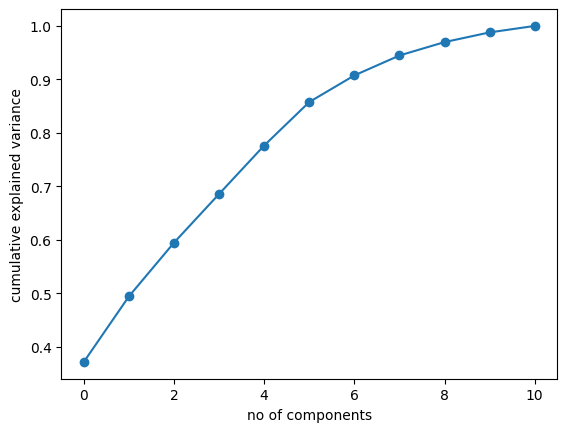

In [ ]:
# visualization

plt.figure()
plt.plot(cum_explained , marker = "o")

plt.xlabel("no of components")
plt.ylabel("cumulative explained variance")

plt.show()





In [ ]:
# k90 o k95 selection

def components_for_theshold(cum_variance, threshold):
  return int(np.argmax(cum_variance >= threshold) +1)



k90 = components_for_theshold(cum_explained , 0.90)
print(k90)

k95 = components_for_theshold(cum_explained , 0.95)
print(k95)


7
9


**Interpretation:**
- `k90` = 90% variance-e pouchate minimum joto component lage
- `k95` = 95% variance-e pouchate minimum joto component lage

Amra `k95` use korbo, shefer reduction-er jonno (kom information loss)।

In [ ]:
#choosing for 95% PCA

k = k95

pca = PCA(n_components = k)

x_pca = pca.fit_transform(X_scaled)

x_pca.shape



(350, 9)

## 7) Feature Reduction-er Jonno PCA: Model Demo (Soho o Chara)

Ekhon amra ekta practical demonstration korbo:
- Original scaled feature diye ekta simple classifier (Logistic Regression) train korbo
- Shei-i classifier PCA-reduced feature diye train korbo

**Important:**
PCA accuracy barabei guarantee kore na।
Eta mainly use hoy:
- Dimension komanor jonno (fast training, simpler representation)
- Redundancy/noise remove korar jonno
- Visualization o stability-r jonno

**Note:** `final_score` ekta continuous number (0-100), kintu classifier demo-r jonno amader ekta category lagbe। Tai amra `final_score`-ke 3 ta tier-e bhag korbo: **Low / Medium / High** — eta hocche amader classification target (`y_class`)।

In [ ]:
# final_score (continuous) theke 3-tier category banano — classification demo-r jonno

y_class = pd.qcut(y, q=3, labels = ["Low", "Medium", "High"])

y_class





,final_score
0,Low
1,Low
2,High
3,Low
4,Low
...,...
345,High
346,High
347,Low
348,Medium


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.25, random_state=42, stratify=y_class
)

# Pipeline WITHOUT PCA: Scale -> Logistic Regression
pipe_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=500))
])

pipe_no_pca.fit(X_train, y_train)
pred_no_pca = pipe_no_pca.predict(X_test)

acc_no_pca = accuracy_score(y_test, pred_no_pca)
print("Accuracy (No PCA):", acc_no_pca)
print("\nClassification Report (No PCA):\n")
print(classification_report(y_test, pred_no_pca))

Accuracy (No PCA): 0.6136363636363636

Classification Report (No PCA):

              precision    recall  f1-score   support

        High       0.77      0.77      0.77        30
         Low       0.67      0.48      0.56        29
      Medium       0.46      0.59      0.52        29

    accuracy                           0.61        88
   macro avg       0.63      0.61      0.61        88
weighted avg       0.63      0.61      0.62        88



### PCA Pipeline

PCA soho Pipeline:
- Scale
- PCA (95% variance rakhar jonno joto component lage)
- Logistic Regression

Ekhane `n_components=0.95` set korle sklearn-ke bola hocche:
"Emon minimum PC shongkha choose koro jate explained variance >= 95% hoy।"

In [ ]:
pipe_with_pca = Pipeline([
    ("scaler", StandardScaler()),
    #add PCA in pipeline

    ("pca", PCA(n_components = 0.95)),
    ("clf", LogisticRegression(max_iter=500))
])

pipe_with_pca.fit(X_train, y_train)
pred_with_pca = pipe_with_pca.predict(X_test)

acc_with_pca = accuracy_score(y_test, pred_with_pca)
print("Accuracy (With PCA):", acc_with_pca)
print("\nClassification Report (With PCA):\n")
print(classification_report(y_test, pred_with_pca))

Accuracy (With PCA): 0.625

Classification Report (With PCA):

              precision    recall  f1-score   support

        High       0.73      0.80      0.76        30
         Low       0.68      0.45      0.54        29
      Medium       0.50      0.62      0.55        29

    accuracy                           0.62        88
   macro avg       0.64      0.62      0.62        88
weighted avg       0.64      0.62      0.62        88



### Result-er Explanation

Jodi PCA accuracy prai kachakachi hoy:
- Bhalo. Amra performance na hariye dimension komate perechi।

Jodi PCA accuracy better hoy:
- PCA hoyto redundancy/noise remove kore diyeche, jeta model-ke confuse korchilo।

Jodi PCA accuracy kharap hoy:
- Amra kono useful information hariye felechi।
- Threshold barao (jemon 0.98), othoba PCA skip koro।

**Bottom line:** PCA ekta tool। Jokhon problem-er condition match kore, tokhon use koro।

## 8) Kokhon PCA Useful (Practical Checklist)

**PCA use koro jokhon:**
- Onek numeric feature ache (10, 50, 500)
- Feature gulo correlated (redundant information)
- Fast training ba simpler representation lagbe
- Measurement-heavy feature-e noise komate chao

**PCA avoid koro jokhon:**
- Original feature-er interpretability important
- Feature already kom o meaningful
- Data mostly categorical

## 9) Summary

Ei notebook e amra shikhlam PCA library diye kivabe apply kora hoy:
- Data scale korlam (critical step)
- PCA fit kore explained variance ratio interpret korlam
- 90% / 95% rule diye component shongkha select korlam
- Dataset ke PCA space e transform korlam
- PCA soho o chara ekta simple model comparison dekhlam
